
Iteration 20 results | k=4
Log Likelihood: 431052.67
Silhouette : 0.18

Cluster Profile (means, original scale) -- Iteration 20 (GaussianMixture + MinMaxScaler, spherical):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
31425,50.66972431387276,1.384,21.3988304560504,38.54110905626683,0.28,0.2746039312451652,0.7683794809232657
18186,29.62107440718612,1.211,22.30101602020627,24.539623570241602,0.594,0.2549471280730658,0.49061599638724146
30821,47.838588155742315,1.362,25.564252920427084,36.07996547450006,0.257,0.3516763932287556,0.4148761640954631
27568,34.015431861636614,1.225,15.25710640527152,28.458036199991085,0.277,0.2468163047902763,0.4670416484426015


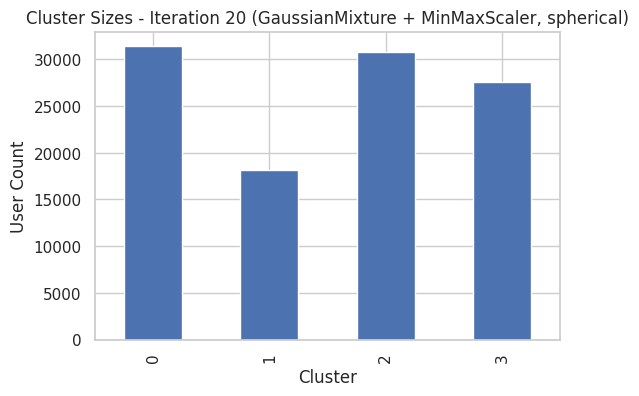

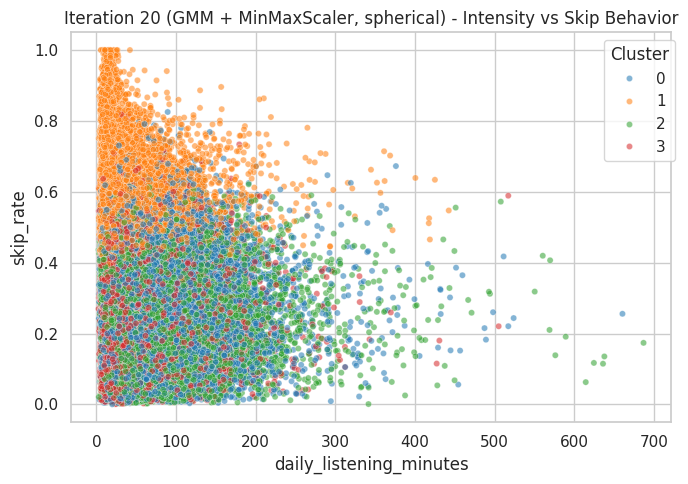

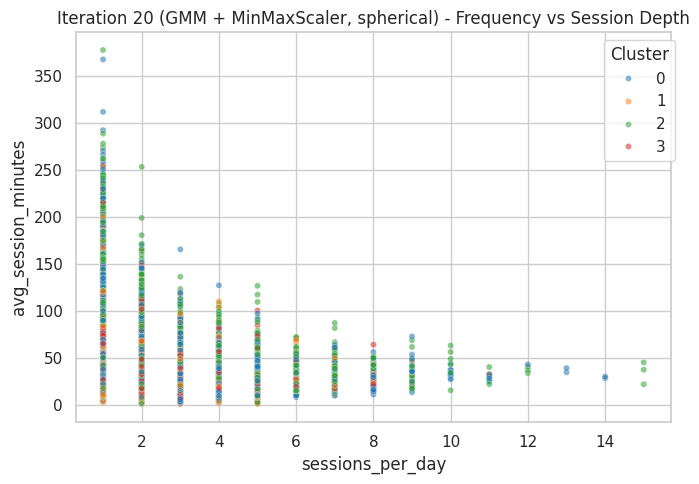

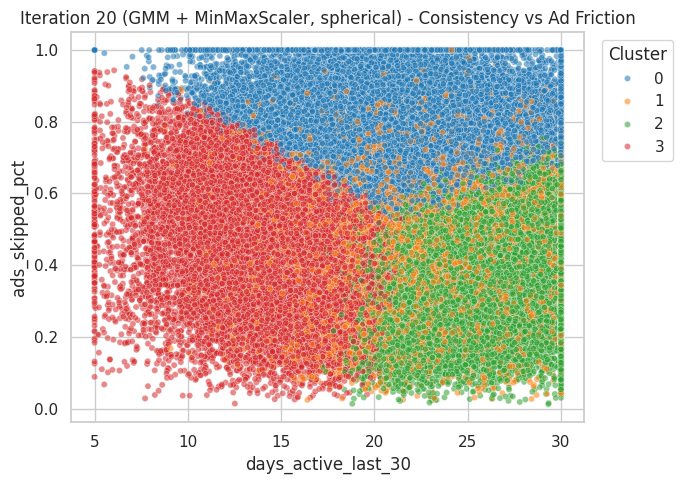

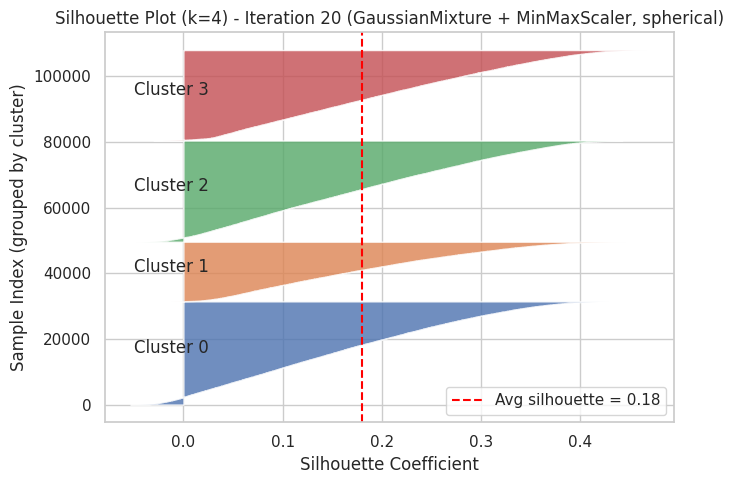

Iteration 20 Avg Silhouette: 0.18


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# -----------------------------
# Load data
# -----------------------------
spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

# -----------------------------
# Feature selection
# -----------------------------
CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes",   # usage intensity
    "sessions_per_day",          # frequency
    "days_active_last_30",       # consistency
    "avg_session_minutes",       # depth
    "skip_rate",                 # content friction
    "liked_songs_pct",           # positive engagement
    "ads_skipped_pct"            # monetization friction
]

base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()

# -----------------------------
# Parameters
# -----------------------------
K = 4

# -----------------------------
# MinMax Scaling
# -----------------------------
X20 = base[CLUSTER_FEATURES_V1].copy()

minmax = MinMaxScaler()
X20_scaled = minmax.fit_transform(X20)

X20 = pd.DataFrame(
    X20_scaled,
    columns=CLUSTER_FEATURES_V1,
    index=base.index
)

# -----------------------------
# Gaussian Mixture Model
# -----------------------------
gmm20 = GaussianMixture(
    n_components=K,
    covariance_type="spherical",
    random_state=42,
    n_init=5,
    max_iter=200
)

labels20 = gmm20.fit_predict(X20)

log_likelihood20 = gmm20.score(X20) * len(X20)
sill_avg_20 = silhouette_score(X20, labels20)

# -----------------------------
# Attach clusters
# -----------------------------
base_iter20 = base.copy()
base_iter20["cluster"] = labels20

print(f"\nIteration 20 results | k={K}")
print("Log Likelihood:", round(log_likelihood20, 3))
print("Silhouette :", round(sill_avg_20, 3))

# -----------------------------
# Cluster profiles
# -----------------------------
sizes20 = base_iter20["cluster"].value_counts().sort_index()
means20 = (
    base_iter20
    .groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

profile20 = means20.copy()
profile20.insert(0, "cluster_size", sizes20)

print("\nCluster Profile (means, original scale) -- Iteration 20 (GaussianMixture + MinMaxScaler, spherical):")
display(profile20)

# -----------------------------
# Cluster size plot
# -----------------------------
plt.figure(figsize=(6,4))
base_iter20["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration 20 (GaussianMixture + MinMaxScaler, spherical)")
plt.xlabel("Cluster")
plt.ylabel("User Count")
plt.show()

# -----------------------------
# Scatter plots
# -----------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter20,
    x="daily_listening_minutes",
    y="skip_rate",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55
)
plt.title("Iteration 20 (GMM + MinMaxScaler, spherical) - Intensity vs Skip Behavior")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter20,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55
)
plt.title("Iteration 20 (GMM + MinMaxScaler, spherical) - Frequency vs Session Depth")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter20,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55
)
plt.title("Iteration 20 (GMM + MinMaxScaler, spherical) - Consistency vs Ad Friction")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

# -----------------------------
# Silhouette Plot (MANUAL – no loop)
# -----------------------------
sil_value_20 = silhouette_samples(X20, labels20)

plt.figure(figsize=(7,5))
y_lower = 0

# Cluster 0
vals0 = sil_value_20[labels20 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals0, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size0, "Cluster 0")
y_lower = y_upper

# Cluster 1
vals1 = sil_value_20[labels20 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals1, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size1, "Cluster 1")
y_lower = y_upper

# Cluster 2
vals2 = sil_value_20[labels20 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size2, "Cluster 2")
y_lower = y_upper

# Cluster 3
vals3 = sil_value_20[labels20 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size3, "Cluster 3")
y_lower = y_upper

plt.axvline(
    x=sill_avg_20,
    color="red",
    linestyle="--",
    label=f"Avg silhouette = {sill_avg_20:.2f}"
)

plt.title("Silhouette Plot (k=4) - Iteration 20 (GaussianMixture + MinMaxScaler, spherical)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample Index (grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()

print("Iteration 20 Avg Silhouette:", round(sill_avg_20, 3))
